# 직장인구 x 상권 

In [147]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [148]:
from pathlib import Path
import pandas as pd

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# ✅ 직장인 데이터
csv_path1 = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_work = pd.read_csv(csv_path1, encoding='cp949')
print(f'직장데이터: {df_work.shape}')

# ✅ 소득소비 데이터
csv_path2 = project_root / 'data' / '11_소득소비' / '서울시 상권분석서비스(소득소비-상권).csv'
df_income = pd.read_csv(csv_path2, encoding='cp949')
print(f'소득소비 데이터: {df_income.shape}')



직장데이터: (45840, 26)
소득소비 데이터: (45590, 17)


In [149]:
df_income = df_income.dropna()

In [150]:
print('=== 직장 데이터 컬럼 ===')
print(df_work.columns.tolist())
print()

print('=== 소득소비 데이터 컬럼 ===')
print(df_income.columns.tolist())
print()

=== 직장 데이터 컬럼 ===
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수', '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수', '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수']

=== 소득소비 데이터 컬럼 ===
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '월_평균_소득_금액', '소득_구간_코드', '지출_총금액', '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액', '의료비_지출_총금액', '교통_지출_총금액', '여가_지출_총금액', '문화_지출_총금액', '교육_지출_총금액', '유흥_지출_총금액']



In [151]:
df_final3 = pd.merge(df_work, df_income,
                       on=['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명'],
                       how='left')

print(df_final3.shape)
print(df_final3.columns.tolist())

(45840, 38)
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수', '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수', '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수', '월_평균_소득_금액', '소득_구간_코드', '지출_총금액', '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액', '의료비_지출_총금액', '교통_지출_총금액', '여가_지출_총금액', '문화_지출_총금액', '교육_지출_총금액', '유흥_지출_총금액']


In [152]:
df_final3.head(5)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,...,지출_총금액,식료품_지출_총금액,의류_신발_지출_총금액,생활용품_지출_총금액,의료비_지출_총금액,교통_지출_총금액,여가_지출_총금액,문화_지출_총금액,교육_지출_총금액,유흥_지출_총금액
0,20254,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20254,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,...,8.751577e+09,1.816409e+09,1.103987e+09,722602116.0,917183031.0,1.534513e+09,468534099.0,243707454.0,1.598783e+09,345857729.0
2,20254,U,관광특구,3001494,종로?청계 관광특구,46516,26098,20418,658,9450,...,1.880810e+09,5.029347e+08,2.421668e+08,151381021.0,253103975.0,3.145640e+08,93975919.0,58322993.0,1.839681e+08,80392486.0
3,20254,U,관광특구,3001493,동대문패션타운 관광특구,33754,16984,16770,259,9770,...,1.889505e+09,4.050555e+08,2.421250e+08,165935630.0,198916229.0,3.278094e+08,100912376.0,55876056.0,3.153858e+08,77489043.0
4,20254,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,199667,114485,85182,372,40531,...,7.990605e+08,1.985431e+08,1.093387e+08,65537299.0,100540265.0,1.451533e+08,47266880.0,23816404.0,7.339274e+07,35471786.0


In [153]:
# NaN 얼마나 있는지 확인
print(df_final3['월_평균_소득_금액'].isna().sum())
print(f'전체 행: {df_final3.shape[0]}')
print(f'NaN 비율: {df_final3["월_평균_소득_금액"].isna().sum() / df_final3.shape[0] * 100:.1f}%')

# 어떤 상권_구분_코드에서 NaN이 많은지 확인
print(df_final3.groupby('상권_구분_코드_명')['월_평균_소득_금액'].apply(lambda x: x.isna().sum()))

1613
전체 행: 45840
NaN 비율: 3.5%
상권_구분_코드_명
골목상권     308
관광특구      28
발달상권     252
전통시장    1025
Name: 월_평균_소득_금액, dtype: int64


In [154]:
df_final3 = df_final3.dropna(subset=['월_평균_소득_금액'])
print(f'dropna 후: {df_final3.shape}')

dropna 후: (44227, 38)


In [155]:
df_final3['식료품_비율'] = df_final3['식료품_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['의류신발_비율'] = df_final3['의류_신발_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['생활용품_비율'] = df_final3['생활용품_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['의료비_비율'] = df_final3['의료비_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['교통_비율'] = df_final3['교통_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['여가_비율'] = df_final3['여가_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['문화_비율'] = df_final3['문화_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['교육_비율'] = df_final3['교육_지출_총금액'] / df_final3['지출_총금액'] * 100
df_final3['유흥_비율'] = df_final3['유흥_지출_총금액'] / df_final3['지출_총금액'] * 100

비율_cols = ['식료품_비율', '의류신발_비율', '생활용품_비율', '의료비_비율', '교통_비율',
             '여가_비율', '문화_비율', '교육_비율', '유흥_비율']

df_final3[비율_cols].round(1)

,식료품_비율,의류신발_비율,생활용품_비율,의료비_비율,교통_비율,여가_비율,문화_비율,교육_비율,유흥_비율
1,20.8,12.6,8.3,10.5,17.5,5.4,2.8,18.3,4.0
2,26.7,12.9,8.0,13.5,16.7,5.0,3.1,9.8,4.3
3,21.4,12.8,8.8,10.5,17.3,5.3,3.0,16.7,4.1
4,24.8,13.7,8.2,12.6,18.2,5.9,3.0,9.2,4.4
5,24.8,12.6,8.4,12.1,17.3,4.4,3.2,13.0,4.3
...,...,...,...,...,...,...,...,...,...
45835,25.0,12.4,7.3,12.7,16.9,4.2,2.9,14.3,4.2
45836,28.9,11.8,7.2,14.1,15.7,3.3,3.2,11.6,4.2
45837,24.9,12.3,7.3,12.6,16.8,4.1,2.9,14.8,4.2
45838,23.7,12.4,7.3,12.2,17.6,4.4,2.8,15.4,4.2


In [156]:
df_final3['남성_비율'] = df_final3['남성_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_비율'] = df_final3['여성_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100

df_final3['연령대_10_비율'] = df_final3['연령대_10_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['연령대_20_비율'] = df_final3['연령대_20_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['연령대_30_비율'] = df_final3['연령대_30_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['연령대_40_비율'] = df_final3['연령대_40_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['연령대_50_비율'] = df_final3['연령대_50_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['연령대_60이상_비율'] = df_final3['연령대_60_이상_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100

df_final3['남성_10대_비율'] = df_final3['남성연령대_10_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['남성_20대_비율'] = df_final3['남성연령대_20_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['남성_30대_비율'] = df_final3['남성연령대_30_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['남성_40대_비율'] = df_final3['남성연령대_40_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['남성_50대_비율'] = df_final3['남성연령대_50_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['남성_60대이상_비율'] = df_final3['남성연령대_60_이상_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100

df_final3['여성_10대_비율'] = df_final3['여성연령대_10_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_20대_비율'] = df_final3['여성연령대_20_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_30대_비율'] = df_final3['여성연령대_30_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_40대_비율'] = df_final3['여성연령대_40_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_50대_비율'] = df_final3['여성연령대_50_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100
df_final3['여성_60대이상_비율'] = df_final3['여성연령대_60_이상_직장_인구_수'] / df_final3['총_직장_인구_수'] * 100

# 확인
인구_비율_cols = [
    '남성_비율', '여성_비율',
    '연령대_10_비율', '연령대_20_비율', '연령대_30_비율',
    '연령대_40_비율', '연령대_50_비율', '연령대_60이상_비율',
    '남성_10대_비율', '남성_20대_비율', '남성_30대_비율',
    '남성_40대_비율', '남성_50대_비율', '남성_60대이상_비율',
    '여성_10대_비율', '여성_20대_비율', '여성_30대_비율',
    '여성_40대_비율', '여성_50대_비율', '여성_60대이상_비율'
]

df_final3[인구_비율_cols].round(1)

,남성_비율,여성_비율,연령대_10_비율,연령대_20_비율,연령대_30_비율,연령대_40_비율,연령대_50_비율,연령대_60이상_비율,남성_10대_비율,남성_20대_비율,남성_30대_비율,남성_40대_비율,남성_50대_비율,남성_60대이상_비율,여성_10대_비율,여성_20대_비율,여성_30대_비율,여성_40대_비율,여성_50대_비율,여성_60대이상_비율
1,59.1,40.9,0.2,16.5,26.2,25.8,22.0,9.3,0.1,8.2,16.5,16.4,11.7,6.2,0.1,8.3,9.7,9.4,10.3,3.1
2,56.1,43.9,1.4,20.3,29.8,27.2,16.0,5.3,0.5,8.8,15.5,16.3,11.3,3.7,0.9,11.6,14.2,10.9,4.7,1.6
3,50.3,49.7,0.8,28.9,25.7,20.4,16.0,8.2,0.3,13.9,14.8,11.6,6.2,3.5,0.5,15.1,10.9,8.8,9.9,4.6
4,57.3,42.7,0.2,20.3,33.4,25.8,15.9,4.4,0.0,7.8,17.6,17.1,11.8,3.0,0.1,12.5,15.8,8.7,4.1,1.4
5,59.2,40.8,0.0,22.7,33.7,23.1,16.6,3.8,0.0,7.8,17.9,16.3,14.1,3.1,0.0,14.9,15.8,6.8,2.6,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45835,55.4,44.6,0.1,16.9,28.8,26.7,19.4,8.0,0.0,6.9,15.9,15.4,11.6,5.5,0.1,10.0,12.9,11.4,7.8,2.5
45836,47.4,52.6,0.0,19.3,28.1,28.1,17.5,7.0,0.0,5.3,10.5,14.0,10.5,7.0,0.0,14.0,17.5,14.0,7.0,0.0
45837,56.0,44.0,0.0,13.0,27.3,31.7,21.3,6.7,0.0,6.0,14.1,18.7,12.8,4.3,0.0,6.9,13.2,13.0,8.5,2.4
45838,27.7,72.3,0.7,27.9,28.2,24.2,12.9,6.1,0.7,5.9,5.6,7.7,4.2,3.5,0.0,22.1,22.5,16.4,8.7,2.6


In [159]:
소비_cols = [
    '식료품_비율', '의류신발_비율', '생활용품_비율',
    '의료비_비율', '교통_비율',
    '여가_비율', '문화_비율', '교육_비율', '유흥_비율'
]

연령_cols = [
    '연령대_10_비율', '연령대_20_비율', '연령대_30_비율',
    '연령대_40_비율', '연령대_50_비율', '연령대_60이상_비율'
]

result = {}

for age in 연령_cols:
    weighted = df_final3[소비_cols].multiply(df_final3[age], axis=0)
    result[age] = weighted.sum() / df_final3[age].sum()

연령별_소비 = pd.DataFrame(result).T.round(2)

연령별_소비

,식료품_비율,의류신발_비율,생활용품_비율,의료비_비율,교통_비율,여가_비율,문화_비율,교육_비율,유흥_비율
연령대_10_비율,25.65,12.41,7.83,12.72,16.65,4.24,3.08,13.16,4.26
연령대_20_비율,25.96,12.32,7.58,12.79,16.24,3.99,3.13,13.72,4.27
연령대_30_비율,26.07,12.29,7.55,12.86,16.20,3.96,3.13,13.68,4.26
연령대_40_비율,26.24,12.26,7.51,12.97,16.12,3.93,3.13,13.60,4.25
연령대_50_비율,26.33,12.24,7.48,13.03,16.09,3.90,3.12,13.56,4.24
연령대_60이상_비율,26.52,12.20,7.46,13.13,16.06,3.88,3.12,13.41,4.23


In [163]:
금액_cols = [
    '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액',
    '의료비_지출_총금액', '교통_지출_총금액',
    '여가_지출_총금액', '문화_지출_총금액',
    '교육_지출_총금액', '유흥_지출_총금액'
]


금액_result = {}

for age in 연령_cols:
    weighted = df_final3[금액_cols].multiply(df_final3[age], axis=0)
    금액_result[age] = weighted.sum() / df_final3[age].sum()

연령별_매출 = pd.DataFrame(금액_result).T.round(0)

# 인덱스 정리
연령별_매출.index = 연령별_매출.index.str.replace('연령대_', '').str.replace('_비율', '')

연령별_매출


,식료품_지출_총금액,의류_신발_지출_총금액,생활용품_지출_총금액,의료비_지출_총금액,교통_지출_총금액,여가_지출_총금액,문화_지출_총금액,교육_지출_총금액,유흥_지출_총금액
10,212116947.0,106859288.0,68050417.0,104274736.0,144588343.0,37384654.0,26281018.0,125143608.0,36213564.0
20,319962916.0,154475546.0,95224973.0,157211000.0,207091660.0,49728538.0,38991362.0,179467751.0,53583965.0
30,327146194.0,156829966.0,96447259.0,160952363.0,210148218.0,50170038.0,39649091.0,181631959.0,54455823.0
40,331113363.0,157256205.0,96401140.0,163192806.0,210418287.0,49967113.0,39828169.0,181216851.0,54648419.0
50,336507505.0,158725961.0,97060000.0,166145620.0,212297310.0,50246136.0,40213212.0,182136534.0,55160953.0
60이상,341540238.0,159883703.0,97802184.0,168591509.0,213916051.0,50462221.0,40569368.0,182201651.0,55574710.0


In [167]:
df_final3.groupby('상권_구분_코드_명')[연령_cols].mean().round(1)

,연령대_10_비율,연령대_20_비율,연령대_30_비율,연령대_40_비율,연령대_50_비율,연령대_60이상_비율
상권_구분_코드_명,,,,,,
골목상권,0.0,13.3,22.7,25.2,23.7,15.1
관광특구,0.6,21.9,29.9,24.2,17.0,6.4
발달상권,0.2,16.8,26.3,25.1,20.3,11.3
전통시장,0.1,13.0,21.9,25.1,23.6,16.2


In [175]:
금액_cols = [
    '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액',
    '의료비_지출_총금액', '교통_지출_총금액',
    '여가_지출_총금액', '문화_지출_총금액',
    '교육_지출_총금액', '유흥_지출_총금액'
]

성별_cols = ['남성_비율', '여성_비율']

성별_평균 = {}

for gender in 성별_cols:
    성별_평균[gender] = df_final3.groupby(gender)[금액_cols].mean()


In [176]:
df_final3['성별_구분'] = df_final3['남성_비율'] > df_final3['여성_비율']
df_final3['성별_구분'] = df_final3['성별_구분'].map({True: '남성', False: '여성'})

성별_평균 = df_final3.groupby('성별_구분')[금액_cols].mean().round(0)

성별_평균

,식료품_지출_총금액,의류_신발_지출_총금액,생활용품_지출_총금액,의료비_지출_총금액,교통_지출_총금액,여가_지출_총금액,문화_지출_총금액,교육_지출_총금액,유흥_지출_총금액
성별_구분,,,,,,,,,
남성,343929357.0,163924807.0,100754897.0,169226969.0,219558089.0,52348861.0,41487093.0,189279438.0,56889823.0
여성,256902809.0,119235144.0,71933036.0,128098373.0,158969088.0,36863517.0,30228682.0,134709393.0,41731182.0


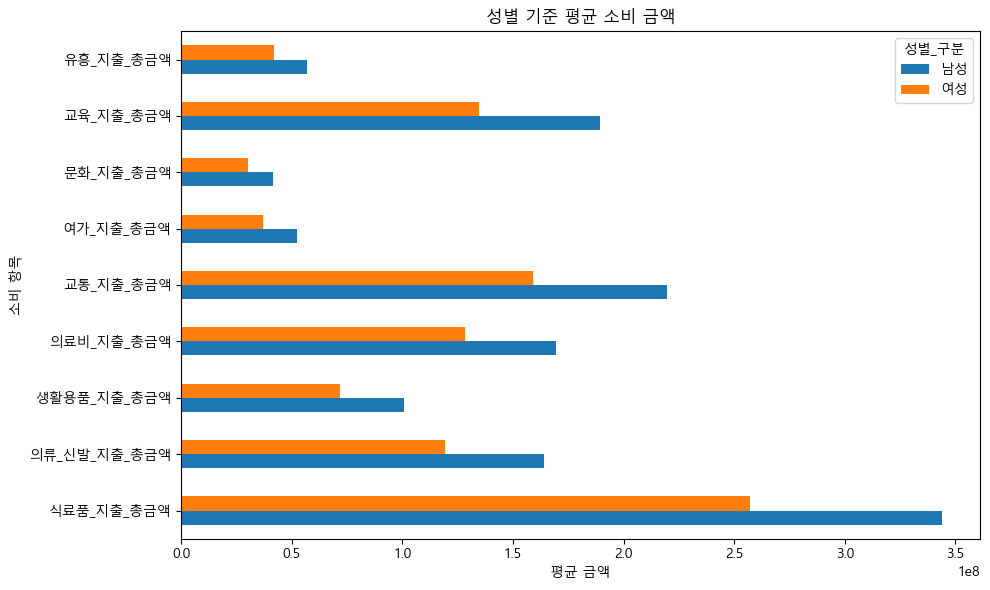

In [179]:
성별_평균.T.plot(kind='barh', figsize=(10,6))

plt.title("성별 기준 평균 소비 금액")
plt.xlabel("평균 금액")
plt.ylabel("소비 항목")

plt.tight_layout()
plt.show()

In [178]:
print(f"남성 직장인구 합계: {df_final3['남성_직장_인구_수'].sum():,.0f}")
print(f"여성 직장인구 합계: {df_final3['여성_직장_인구_수'].sum():,.0f}")
print(f"남성 비율: {df_final3['남성_직장_인구_수'].sum() / df_final3['총_직장_인구_수'].sum() * 100:.1f}%")
print(f"여성 비율: {df_final3['여성_직장_인구_수'].sum() / df_final3['총_직장_인구_수'].sum() * 100:.1f}%")

남성 직장인구 합계: 71,194,747
여성 직장인구 합계: 45,718,069
남성 비율: 60.9%
여성 비율: 39.1%
